In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42

In [23]:
galmet = pd.read_csv("../meta_apal_20260413_2338.csv")

In [24]:
galmet = galmet.rename(columns = {"affymetrix_id": "Affymetrix ID", "mlg": "Coral Mlg Clonal ID"})

In [25]:
curated_meta = pd.read_csv("../curated_metadata.tsv", 
                           sep = "\t").merge(galmet[["Affymetrix ID", 
                                                     'Coral Mlg Clonal ID']],
                                             how = "left", on = "Affymetrix ID")

In [26]:
het = pd.read_csv("../filtered_calls/het.het", sep = "\t")
het["HET"] = (het["N_SITES"] - het["O(HOM)"]) / het["N_SITES"]
lowhet = het["INDV"][het["HET"] < (het.HET.mean() - (het.HET.std()*3))].tolist()

In [8]:
%%bash
source ~/.bashrc
conda activate orbicella
bcftools query -l ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered_indvmissfiltered.vcf.gz \
    > ../king_samples_metadata.txt

In [27]:
samples = pd.read_csv("../king_samples_metadata.txt", header = None, names = ["Affymetrix ID"]).merge(galmet, how = "left", on = "Affymetrix ID")

In [28]:
samples = samples[~samples["Affymetrix ID"].isin(lowhet)].reset_index(drop=True)

In [55]:
%%bash
source ~/.bashrc
conda activate orbicella
plink2 --vcf ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered_indvmissfiltered.vcf.gz \
    --king-cutoff 0.353 --out king_plots

PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to king_plots.log.
Options in effect:
  --king-cutoff 0.353
  --out king_plots
  --vcf ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered_indvmissfiltered.vcf.gz

Start time: Wed Apr 29 16:51:50 2026
771373 MiB RAM detected, ~694462 available; reserving 385686 MiB for main
workspace.
Using up to 8 compute threads.
--vcf: 18258 variants scanned.
--vcf: king_plots-temporary.pgen + king_plots-temporary.pvar.zst +
king_plots-temporary.psam written.
1397 samples (0 females, 0 males, 1397 ambiguous; 1397 founders) loaded from
king_plots-temporary.psam.
Note: 14 nonstandard chromosome codes present.
18258 variants loaded from king_plots-temporary.pvar.zst.
Note: No phenotype data present.
--king-cutoff pass 1/1: Scanning for rare variants... done.
9818 variants handled by initial scan (8440 remaining).
--king-cutoff

In [56]:
%%bash
source ~/.bashrc
conda activate orbicella
plink2 --vcf ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered_indvmissfiltered.vcf.gz \
    --make-king-table --keep king_plots.king.cutoff.in.id --out king_plots

PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to king_plots.log.
Options in effect:
  --keep king_plots.king.cutoff.in.id
  --make-king-table
  --out king_plots
  --vcf ../filtered_calls/allsamples_lifted_to_jaAcrPala1.3_conffiltered_indvmissfiltered.vcf.gz

Start time: Wed Apr 29 16:51:53 2026
771373 MiB RAM detected, ~694462 available; reserving 385686 MiB for main
workspace.
Using up to 8 compute threads.
--vcf: 18258 variants scanned.
--vcf: king_plots-temporary.pgen + king_plots-temporary.pvar.zst +
king_plots-temporary.psam written.
1397 samples (0 females, 0 males, 1397 ambiguous; 1397 founders) loaded from
king_plots-temporary.psam.
Note: 14 nonstandard chromosome codes present.
18258 variants loaded from king_plots-temporary.pvar.zst.
Note: No phenotype data present.
--keep: 1355 samples remaining.
1355 samples (0 females, 0 males, 1355 ambiguous; 1355 founde

In [57]:
king = pd.read_csv("./king_plots.kin0", sep = "\t")

In [59]:
test = samples.value_counts(["region", "reef"]).reset_index(drop=False).sort_values(["region", "reef"]).reset_index(drop=True)

In [60]:
pca_color_dict = {"Florida": "#FF9896", 
                 'Jamaica': "#C5B0D5", 
                 'Puerto Rico': "#E377C2", 
                 'Colombia': "#FF7F0E", 
                 'Curacao': "#98DF8A", 
                 'USVI': "#F7B6D2", 
                 'Honduras': "#9467BD", 
                 'Cuba': "#2CA02C", 
                 'Dominican Republic': "#D62728", 
                 'Belize': "#AEC7E8"}

/dss/work/noge4093/miniconda3/envs/orbicella/lib/python3.9/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/dss/work/noge4093/miniconda3/envs/orbicella/lib/python3.9/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/dss/work/noge4093/miniconda3/envs/orbicella/lib/python3.9/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/dss/work/noge4093/miniconda3/envs/orbicella/lib/python3.9/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to acc

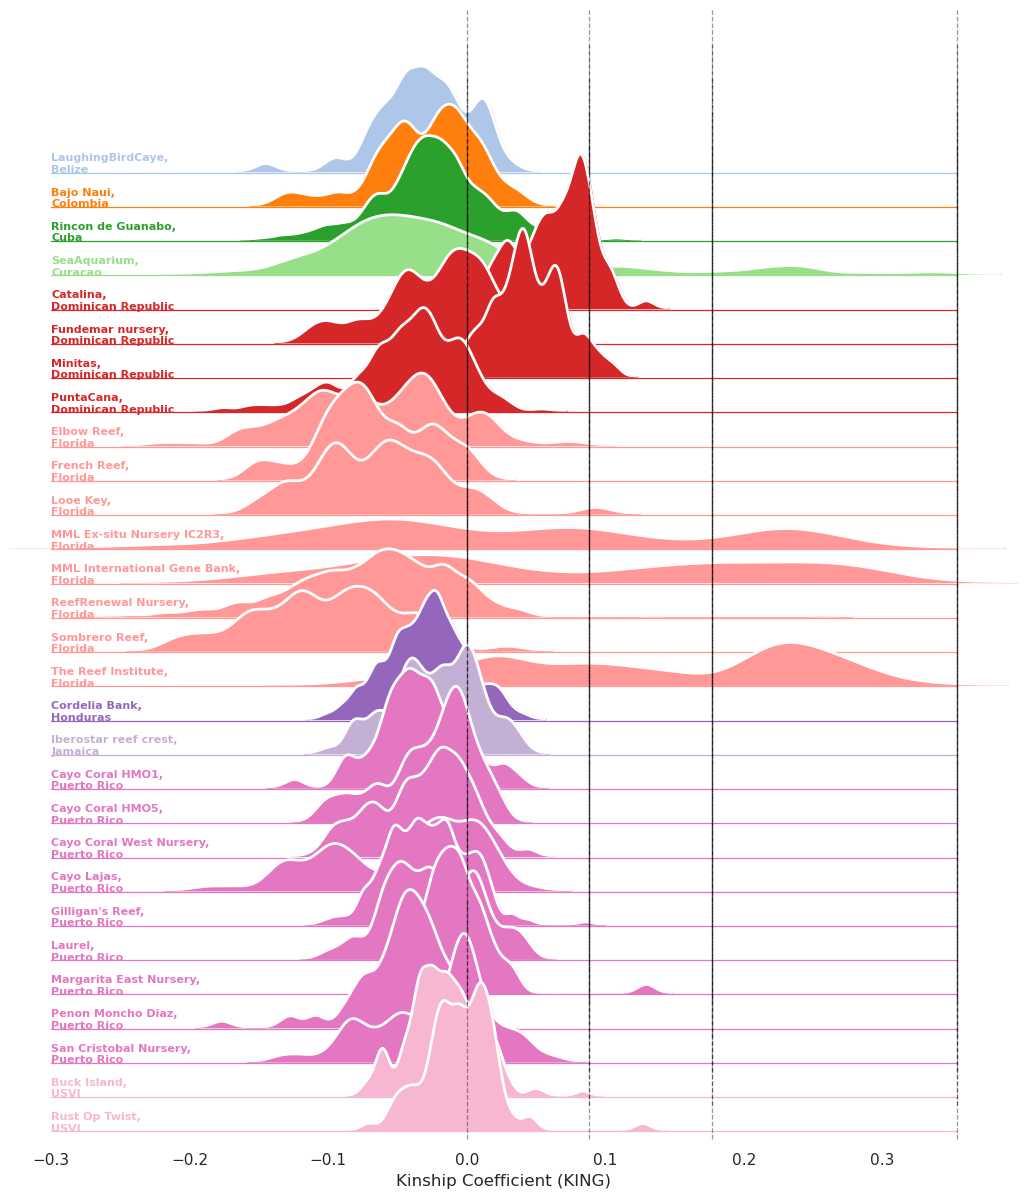

In [74]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Build combined dataframe
ridge_data = []
reefs = test["reef"][test["count"] > 10].tolist()
reefs = [i for i in reefs if i not in [
    'Elbow and Brewster Batch Cross', "-9", 'Sexual Recruit',
    'Elbow reef, Horseshoe, Sand Island batch crosses',
    "Looe Key Bouys 10+11, 2-parent cross", "Looe Key Bouys 10-11"
]]

for reef in reefs:
    regsamps = samples.loc[samples["reef"] == reef, "Affymetrix ID"]

    kin_vals = king.loc[
        king["#IID1"].isin(regsamps) & king["IID2"].isin(regsamps),
        "KINSHIP"
    ]
    
    tmp = pd.DataFrame({
        "KINSHIP": kin_vals,
        "reef": reef
    })
    ridge_data.append(tmp)

ridge_df = pd.concat(ridge_data)

ridge_df = ridge_df.merge(
    samples[["region", "reef"]].drop_duplicates(),
    how="left",
    on="reef"
).reset_index(drop=True)

# =========================
# ✅ Use your custom color dict
# =========================
# pca_color_dict = {"region_name": "#hexcode", ...}

# Ensure all regions have a defined color
regions_in_data = ridge_df["region"].unique()
missing = set(regions_in_data) - set(pca_color_dict.keys())

if missing:
    raise ValueError(f"Missing colors for regions: {missing}")

palette = {region: pca_color_dict[region] for region in regions_in_data}

# Plot
sns.set(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

g = sns.FacetGrid(
    ridge_df,
    row="reef",
    hue="region",
    aspect=15,
    height=0.5,
    palette=palette
)

# Set overall figure size
g.figure.set_size_inches(10, 12)

# Set x limits
g.set(xlim=(-0.3, (0.5 * 0.25) ** 0.5))

# 👉 Adaptive KDE using variance + sample size (Scott's rule style)
def kde_adaptive(x, color, **kwargs):
    ax = plt.gca()
    
    x = np.asarray(x)
    n = len(x)
    
    if n < 5:
        return
    
    sigma = np.std(x, ddof=1)
    
    # Scott's rule bandwidth
    bw = sigma * (n ** (-1/5))
    
    # Normalize bandwidth
    sigma_ref = ridge_df["KINSHIP"].std()
    bw_adjust = bw / sigma_ref if sigma_ref > 0 else 1
    
    # Clamp
    bw_adjust = max(0.5, min(bw_adjust, 1.5))
    
    sns.kdeplot(
        x=x,
        bw_adjust=bw_adjust,
        fill=True,
        color=color,
        alpha=1,
        linewidth=1.5,
        clip_on=False,
        ax=ax
    )
    
    sns.kdeplot(
        x=x,
        bw_adjust=bw_adjust,
        color="w",
        lw=2,
        clip_on=False,
        ax=ax
    )

# Apply KDE
g.map(kde_adaptive, "KINSHIP")

# Reference lines
g.map(plt.axhline, y=-0.23, lw=0.9, clip_on=False)
g.map(plt.axvline, x=0, lw=0.9, linestyle="--", color="black", clip_on=False, alpha=0.4)
g.map(plt.axvline, x=(0.125 * 0.0625) ** 0.5, lw=0.9, linestyle="--", color="black", clip_on=False, alpha=0.4)
g.map(plt.axvline, x=(0.25 * 0.125) ** 0.5, lw=0.9, linestyle="--", color="black", clip_on=False, alpha=0.4)
g.map(plt.axvline, x=(0.5 * 0.25) ** 0.5, lw=0.9, linestyle="--", color="black", clip_on=False, alpha=0.4)

# Labels: Reef Name + Region
for ax, reef_name in zip(g.axes.flat, g.row_names):
    region = ridge_df.loc[ridge_df["reef"] == reef_name, "region"].iloc[0]
    
    ax.text(
        0,
        0.1,
        f"{reef_name},\n{region}",
        fontsize=8,
        fontweight="bold",
        color=palette[region],
        ha="left",
        va="center",
        transform=ax.transAxes
    )

# Overlap ridges
g.figure.subplots_adjust(hspace=-0.8)

# Clean up axes
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)

plt.xlabel("Kinship Coefficient (KING)")
plt.savefig("../figures/king_site_relatedness.pdf", dpi=300)

In [62]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

In [63]:
regsamps = samples.copy()
kin_vals = (king[king["KINSHIP"] > 0.088]
            [king["#IID1"] != "121166513_(Axiom_AcropSNP)_C01.CEL"]
            [king["IID2"] != "121166513_(Axiom_AcropSNP)_C01.CEL"]).copy()
df = kin_vals.merge(
    samples,
    left_on="#IID1",
    right_on="Affymetrix ID",
    how="left"
).rename(columns={
    "lat_clean": "lat1",
    "lon_clean": "lon1"
}).drop(columns=["Affymetrix ID"])

# Merge for IID2
df = df.merge(
    samples,
    left_on="IID2",
    right_on="Affymetrix ID",
    how="left"
).rename(columns={
    "lat_clean": "lat2",
    "lon_clean": "lon2"
}).drop(columns=["Affymetrix ID"])

/fs/s6k/fast/scratch/16475825_noge4093_mpcs055/ipykernel_549481/2485539655.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  kin_vals = (king[king["KINSHIP"] > 0.088]
/fs/s6k/fast/scratch/16475825_noge4093_mpcs055/ipykernel_549481/2485539655.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  kin_vals = (king[king["KINSHIP"] > 0.088]


In [64]:
df["distance_km"] = haversine(
df["lat1"], df["lon1"],
df["lat2"], df["lon2"]
)

df = df[["#IID1", "IID2", "reef_x", "reef_y", "region_x", "region_y", "distance_km", "lat1", "lon1", "lat2", "lon2", "KINSHIP"]]

In [66]:
df[df["region_x"].notna()][df["region_y"].notna()].sort_values("distance_km").to_csv("../kinship_distance_final.csv", index = False)

/fs/s6k/fast/scratch/16475825_noge4093_mpcs055/ipykernel_549481/2048213609.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[df["region_x"].notna()][df["region_y"].notna()].sort_values("distance_km").to_csv("../kinship_distance_final.csv", index = False)


In [73]:
df[df["reef_x"] == df["reef_y"]][((df["region_x"] != "Florida" ) & (df["region_y"] != "Florida"))].head(60)

/fs/s6k/fast/scratch/16475825_noge4093_mpcs055/ipykernel_549481/3739502133.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[df["reef_x"] == df["reef_y"]][((df["region_x"] != "Florida" ) & (df["region_y"] != "Florida"))].head(60)


,#IID1,IID2,reef_x,reef_y,region_x,region_y,distance_km,lat1,lon1,lat2,lon2,KINSHIP
678,121170129_(Axiom_AcropSNP)_C17.CEL,121170117_(Axiom_AcropSNP)_A17.CEL,MEXICO,MEXICO,Mexico,Mexico,0.000000,21.05000,-86.75000,21.05000,-86.75000,0.157301
679,121170141_(Axiom_AcropSNP)_E17.CEL,121170117_(Axiom_AcropSNP)_A17.CEL,MEXICO,MEXICO,Mexico,Mexico,0.000000,21.05000,-86.75000,21.05000,-86.75000,0.131900
680,121170141_(Axiom_AcropSNP)_E17.CEL,121170129_(Axiom_AcropSNP)_C17.CEL,MEXICO,MEXICO,Mexico,Mexico,0.000000,21.05000,-86.75000,21.05000,-86.75000,0.133640
681,121170153_(Axiom_AcropSNP)_G17.CEL,121170117_(Axiom_AcropSNP)_A17.CEL,MEXICO,MEXICO,Mexico,Mexico,0.000000,21.05000,-86.75000,21.05000,-86.75000,0.105859
682,121170153_(Axiom_AcropSNP)_G17.CEL,121170129_(Axiom_AcropSNP)_C17.CEL,MEXICO,MEXICO,Mexico,Mexico,0.000000,21.05000,-86.75000,21.05000,-86.75000,0.233939
683,121170153_(Axiom_AcropSNP)_G17.CEL,121170141_(Axiom_AcropSNP)_E17.CEL,MEXICO,MEXICO,Mexico,Mexico,0.000000,21.05000,-86.75000,21.05000,-86.75000,0.097854
684,121170165_(Axiom_AcropSNP)_I17.CEL,121170117_(Axiom_AcropSNP)_A17.CEL,MEXICO,MEXICO,Mexico,Mexico,0.000000,21.05000,-86.75000,21.05000,-86.75000,0.096250
685,121170165_(Axiom_AcropSNP)_I17.CEL,121170129_(Axiom_AcropSNP)_C17.CEL,MEXICO,MEXICO,Mexico,Mexico,0.000000,21.05000,-86.75000,21.05000,-86.75000,0.095816
686,121170165_(Axiom_AcropSNP)_I17.CEL,121170141_(Axiom_AcropSNP)_E17.CEL,MEXICO,MEXICO,Mexico,Mexico,0.000000,21.05000,-86.75000,21.05000,-86.75000,0.122251
1025,121178097_(Axiom_AcropSNP)_C03.CEL,121178086_(Axiom_AcropSNP)_A05.CEL,Rincon de Guanabo,Rincon de Guanabo,Cuba,Cuba,0.000000,23.17320,-82.09930,23.17320,-82.09930,0.107926
